In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate,
    MultiHeadAttention, Reshape, Flatten, LayerNormalization
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# --- 1. Define File Paths (from your notebook) ---
base_path_xray = "/content/drive/MyDrive/Breast_cancer_dataset/MultiModel Breast Cancer MSI Dataset/Chest_XRay_MSI"
base_path_histo = "/content/drive/MyDrive/Breast_cancer_dataset/MultiModel Breast Cancer MSI Dataset/Histopathological_MSI"
base_path_ultra = "/content/drive/MyDrive/Breast_cancer_dataset/MultiModel Breast Cancer MSI Dataset/Ultrasound Images_MSI"

# --- 2. Helper function to load dataframes ---
def load_dataframe(base_path, categories):
    image_paths = []
    labels = []
    for category in categories:
        category_path = os.path.join(base_path, category)
        if not os.path.isdir(category_path):
            print(f"Warning: Directory not found - {category_path}")
            continue
        for image_name in os.listdir(category_path):
            image_path = os.path.join(category_path, image_name)
            image_paths.append(image_path)
            labels.append(category)
    return pd.DataFrame({'image_path': image_paths, 'label': labels})

# --- 3. Load all three datasets ---
df_xray = load_dataframe(base_path_xray, ["Malignant", "Normal"])
df_histo = load_dataframe(base_path_histo, ["malignant", "benign"])
df_ultra = load_dataframe(base_path_ultra, ["malignant", "benign"])

print(f"Original X-Ray samples: {len(df_xray)}")
print(f"Original Histo samples: {len(df_histo)}")
print(f"Original Ultra samples: {len(df_ultra)}")

# --- 4. Unify Labels ---
# 0 = Benign/Normal, 1 = Malignant
label_mapping = {
    'Malignant': 1, 'Normal': 0,
    'malignant': 1, 'benign': 0
}
df_xray['label'] = df_xray['label'].map(label_mapping)
df_histo['label'] = df_histo['label'].map(label_mapping)
df_ultra['label'] = df_ultra['label'].map(label_mapping)

# --- 5. Align Datasets (Simulation) ---
# We simulate a multi-modal dataset by sampling to match the smallest dataset
min_samples = min(len(df_xray), len(df_histo), len(df_ultra))
print(f"Aligning all datasets to the smallest size: {min_samples}")

def sample_df(df, n_samples):
    # If the requested sample size is the same as the dataframe size, return the original dataframe
    if len(df) == n_samples:
        return df.reset_index(drop=True)
    # Otherwise, perform stratified sampling
    df_sampled, _ = train_test_split(df, train_size=n_samples, test_size=None, stratify=df['label'], random_state=42)
    return df_sampled.reset_index(drop=True)

df_xray_sampled = sample_df(df_xray, min_samples)
df_histo_sampled = sample_df(df_histo, min_samples)
df_ultra_sampled = sample_df(df_ultra, min_samples)

# --- 6. Create Master DataFrame ---
# We take the labels from the Ultrasound dataset as the "ground truth"
# In a real scenario, all labels should already be identical.
master_df = pd.DataFrame({
    'xray_path': df_xray_sampled['image_path'],
    'histo_path': df_histo_sampled['image_path'],
    'ultra_path': df_ultra_sampled['image_path'],
    'label': df_ultra_sampled['label'] # Using one label set as the master
})

print("\n--- Master DataFrame Created ---")
print(master_df.info())
print("\nLabel distribution in master dataset:")
print(master_df['label'].value_counts())

Original X-Ray samples: 1000
Original Histo samples: 1246
Original Ultra samples: 806
Aligning all datasets to the smallest size: 806

--- Master DataFrame Created ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   xray_path   806 non-null    object
 1   histo_path  806 non-null    object
 2   ultra_path  806 non-null    object
 3   label       806 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 25.3+ KB
None

Label distribution in master dataset:
label
0    406
1    400
Name: count, dtype: int64


In [ ]:
IMG_SIZE = 224

def load_and_preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not read image {path}")
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

print("\nLoading and preprocessing all images...")
# Load all images into numpy arrays
xray_images = np.array([load_and_preprocess_image(p) for p in master_df['xray_path']])
histo_images = np.array([load_and_preprocess_image(p) for p in master_df['histo_path']])
ultra_images = np.array([load_and_preprocess_image(p) for p in master_df['ultra_path']])

labels = master_df['label'].values

print(f"X-ray image array shape: {xray_images.shape}")
print(f"Histo image array shape: {histo_images.shape}")
print(f"Ultra image array shape: {ultra_images.shape}")
print(f"Label array shape: {labels.shape}")

# --- Define Feature Extractors ---
def create_extractor(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = EfficientNetB0(include_top=False, input_shape=input_shape, weights='imagenet')
    base_model.trainable = False  # Freeze weights

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    outputs = GlobalAveragePooling2D()(x)

    return Model(inputs, outputs)

extractor_xray = create_extractor()
extractor_histo = create_extractor()
extractor_ultra = create_extractor()

# --- Extract features ---
print("\nExtracting features using transfer learning...")
features_xray = extractor_xray.predict(xray_images)
features_histo = extractor_histo.predict(histo_images)
features_ultra = extractor_ultra.predict(ultra_images)

# --- 4. Create Fused Feature Set ---
combined_features = np.concatenate([features_xray, features_histo, features_ultra], axis=1)

print(f"Shape of X-Ray features: {features_xray.shape}")
print(f"Shape of Histo features: {features_histo.shape}")
print(f"Shape of Ultra features: {features_ultra.shape}")
print(f"Shape of combined features: {combined_features.shape}")


Loading and preprocessing all images...
X-ray image array shape: (806, 224, 224, 3)
Histo image array shape: (806, 224, 224, 3)
Ultra image array shape: (806, 224, 224, 3)
Label array shape: (806,)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Extracting features using transfer learning...
26/26 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step
Shape of X-Ray features: (806, 1280)
Shape of Histo features: (806, 1280)
Shape of Ultra features: (806, 1280)
Shape of combined features: (806, 3840)


In [ ]:
# --- 1. Train-Test Split ---
# We split the *original* combined features to create a realistic test set
X_train, X_test, y_train, y_test = train_test_split(
    combined_features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"\nOriginal training features shape: {X_train.shape}")
print(f"Original test features shape: {X_test.shape}")
print(f"Original training label distribution: {np.bincount(y_train)}")
print(f"Original test label distribution: {np.bincount(y_test)}")

# --- 2. Apply SMOTE to Training Data ---
print("\nApplying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled training features shape: {X_train_res.shape}")
print(f"Resampled training label distribution: {np.bincount(y_train_res)}")


Original training features shape: (644, 3840)
Original test features shape: (162, 3840)
Original training label distribution: [324 320]
Original test label distribution: [82 80]

Applying SMOTE to training data...
Resampled training features shape: (648, 3840)
Resampled training label distribution: [324 324]


In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, MultiHeadAttention, Reshape, Flatten, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

def build_enhanced_fusion_model(input_shape):
    """
    Builds an enhanced model with a Multi-Head Attention layer
    on top of the concatenated features.
    """
    inputs = Input(shape=(input_shape,))

    # --- Attention Mechanism ---
    # We must reshape the 1D feature vector to 3D (batch, steps, features) for attention
    # We treat the concatenated vector as a single "time step"
    reshaped_features = Reshape((1, input_shape))(inputs)

    # Layer Normalization before Attention
    norm_features = LayerNormalization()(reshaped_features)

    # Multi-Head Attention layer. This is the core enhancement.
    # It learns which parts of the fused feature vector are most important.
    # num_heads=8 and key_dim=128 are good starting points.
    attention_output = MultiHeadAttention(
        num_heads=8,
        key_dim=128
    )(norm_features, norm_features)

    attention_output_flat = Flatten()(attention_output)

    # --- Hybrid Fusion ---
    # We combine the original features with the "attended" features
    # This acts like a residual connection, ensuring no information is lost
    fused_vector = Concatenate()([inputs, attention_output_flat])

    # --- Classifier Head (with extra layers) ---
    # Adding L2 regularization to Dense layers to combat overfitting
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(fused_vector)
    x = Dropout(0.5)(x)  # Increased dropout

    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)  # Increased dropout

    x = Dense(128, activation='relu')(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.0001), # Slower learning rate for fine-tuning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Get the input shape from our resampled training data
input_shape = X_train_res.shape[1]
model = build_enhanced_fusion_model(input_shape)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 3840)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 3840)   │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 3840)   │      7,680 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 3840)   │ 15,735,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3840)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7680)      │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  3,932,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,840,257 (75.68 MB)

 Trainable params: 19,840,257 (75.68 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for robust training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=1e-7
)

print("\n--- Starting Model Training ---")
history = model.fit(
    X_train_res,
    y_train_res,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


--- Starting Model Training ---
Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.5563 - loss: 1.9949 - val_accuracy: 0.7901 - val_loss: 1.8347 - learning_rate: 1.0000e-04
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7700 - loss: 1.7667 - val_accuracy: 0.8210 - val_loss: 1.6585 - learning_rate: 1.0000e-04
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9153 - loss: 1.5030 - val_accuracy: 0.8457 - val_loss: 1.5606 - learning_rate: 1.0000e-04
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9763 - loss: 1.3006 - val_accuracy: 0.8827 - val_loss: 1.4838 - learning_rate: 1.0000e-04
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9650 - loss: 1.2279 - val_accuracy: 0.8765 - val_loss: 1.5331 - learning_rate: 1.0000e-04
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9678 - loss: 1.1868 - val_accuracy: 0.8951 - val_loss: 1.4606 - learning_rate: 1.0000e-04
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━


--- Evaluating Model ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step
Overall Test Accuracy: 0.9321
AUC Score: 0.9765
Sensitivity (Recall): 0.9500
Specificity: 0.9146
Precision: 0.9157

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.95      0.91      0.93        82
Malignant (1)       0.92      0.95      0.93        80

     accuracy                           0.93       162
    macro avg       0.93      0.93      0.93       162
 weighted avg       0.93      0.93      0.93       162



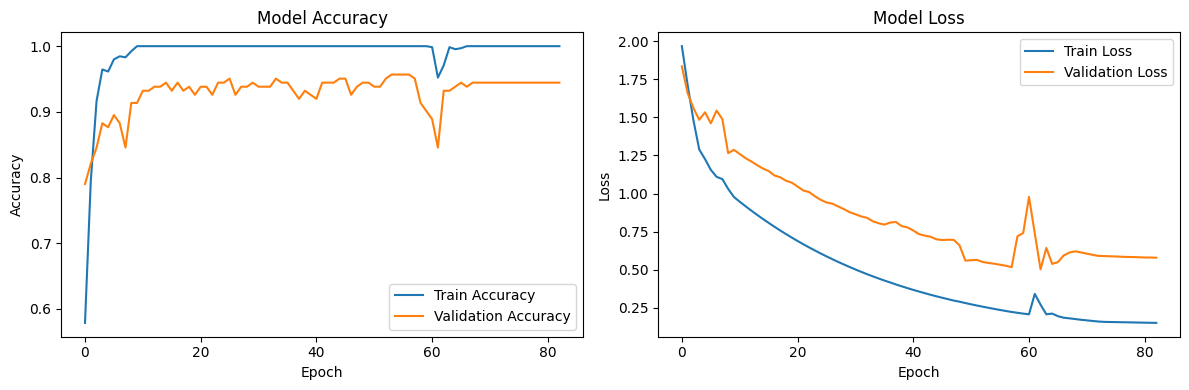

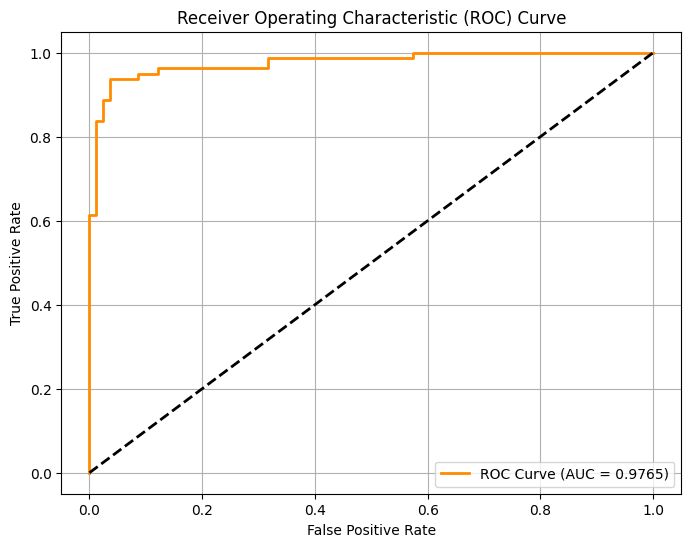

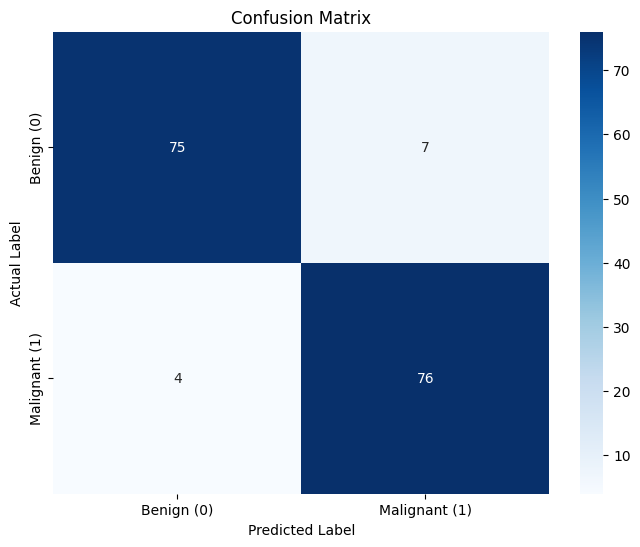

In [ ]:
print("\n--- Evaluating Model ---")

# 1. Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_prob)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"Overall Test Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

# 3. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

# 4. Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 6. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# After training, add this to your code
extractor_xray.save('extractor_xray.h5')
extractor_histo.save('extractor_histo.h5')
extractor_ultra.save('extractor_ultra.h5')
model.save('fusion_model.h5')